# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


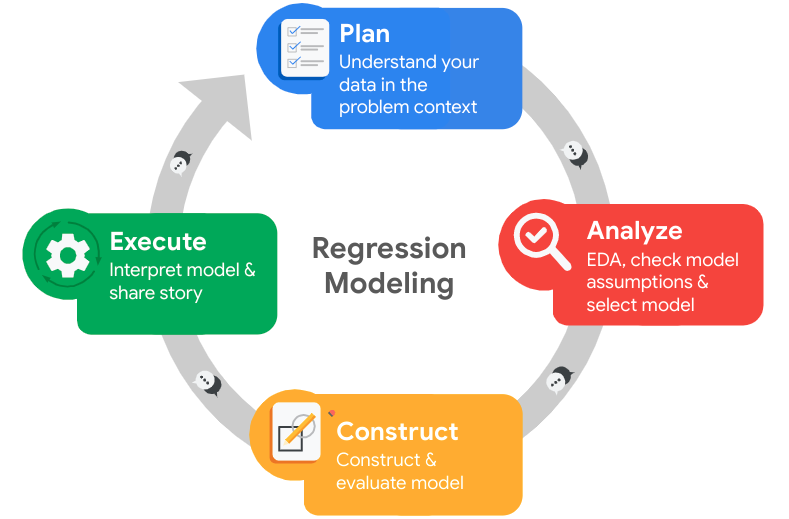

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [84]:
# Import packages
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
!pip install category_encoders
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

You should consider upgrading via the '/opt/conda/bin/python3 -m pip install --upgrade pip' command.


### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={'average_montly_hours': 'average_monthly_hours', 'time_spend_company': 'time_with_company', 'Work_accident': 'work_accident', 'Department': 'dept'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_with_company', 'work_accident', 'left',
       'promotion_last_5years', 'dept', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().any(axis=1).sum()

0

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
df0.duplicated().value_counts()

False    11991
True      3008
dtype: int64

In [9]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_with_company,work_accident,left,promotion_last_5years,dept,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates()

# Display first few rows of new dataframe as needed
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_with_company,work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

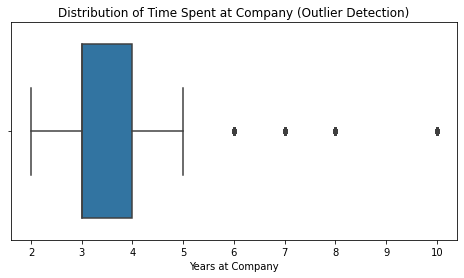

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

# Create the boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['time_with_company'])

# Add labels and title
plt.title('Distribution of Time Spent at Company (Outlier Detection)')
plt.xlabel('Years at Company')

# Display the plot
plt.show()




In [12]:
# Determine the number of rows containing outliers
def get_outlier_rows (dataframe, col):
    #returns a dataframe containing outliers
    q1 = dataframe[col].quantile(.25)
    q3 = dataframe[col].quantile(.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]

get_outlier_rows(df, 'time_with_company').count()
    

satisfaction_level       824
last_evaluation          824
number_project           824
average_monthly_hours    824
time_with_company        824
work_accident            824
left                     824
promotion_last_5years    824
dept                     824
salary                   824
dtype: int64

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [13]:
# Get numbers of people who left vs. stayed
print(df['left'].value_counts())
# Get percentages of people who left vs. stayed
print(df['left'].value_counts(normalize=True))


0    10000
1     1991
Name: left, dtype: int64
0    0.833959
1    0.166041
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

In [14]:
# First, inspect categorical data
df['dept'].unique()
#dept is a categorical column with no order. I could use one-hot encoding, but that will add a lot of columns.
#Since I am planning on a tree based model, I'm going with target encoding. I will encode this later, after splitting data

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [15]:
#Let's look at salary. 
df['salary'].unique()
#ordinal encoding
# Define the strict logical ordering
salary_map = {'low': 1, 'medium': 2, 'high': 3}

# Apply the mapping to the dataframe
df['salary_encoded'] = df['salary'].map(salary_map)
df_encoded = df.drop(columns='salary')
df_encoded.sample(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_with_company,work_accident,left,promotion_last_5years,dept,salary_encoded
9172,0.29,0.43,6,175,3,0,0,0,sales,1
2846,0.74,0.38,2,126,3,0,0,0,sales,2
4135,0.16,0.74,5,205,4,1,0,0,sales,1
7462,0.32,0.41,3,138,3,1,0,0,technical,2
5969,0.22,0.90,4,106,2,0,0,0,sales,2
2718,0.56,0.75,5,143,5,0,0,0,support,2
8058,0.60,0.49,5,259,4,0,0,0,technical,1
8827,0.78,0.63,4,265,3,0,0,0,support,2
10658,0.63,0.78,4,275,3,0,0,0,support,1
2417,0.48,0.49,4,242,2,1,0,0,support,2


In [16]:
#Let's make a new variable so we can see salary relative to department.
# 1. Calculate the mean numerical salary rank for each department
dept_avg_salary = df_encoded.groupby('dept')['salary_encoded'].transform('mean')

# 2. Create the relative salary metric
df_encoded['relative_salary_dept'] = df['salary_encoded'] / dept_avg_salary
df_encoded.sample(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_with_company,work_accident,left,promotion_last_5years,dept,salary_encoded,relative_salary_dept
11775,0.66,0.72,4,271,3,0,0,0,sales,1,0.627470
8254,0.80,0.81,5,156,2,0,0,0,sales,1,0.627470
5158,0.86,0.96,4,167,3,0,0,0,support,3,1.883144
6309,0.94,0.66,5,219,3,0,0,0,support,1,0.627715
10035,0.51,0.72,3,242,3,0,0,0,technical,1,0.638225
4039,0.89,0.73,4,171,4,0,0,0,RandD,2,1.247080
4666,0.87,0.62,5,197,2,0,0,0,sales,1,0.627470
9245,0.52,0.82,4,198,4,0,0,0,sales,1,0.627470
7923,0.98,0.87,5,151,6,0,0,0,IT,2,1.261797
6036,0.97,0.47,3,157,4,0,0,0,marketing,1,0.612933


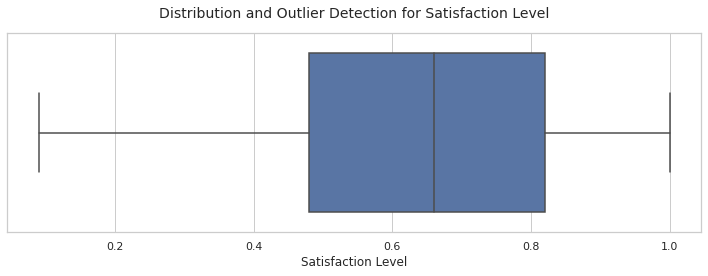

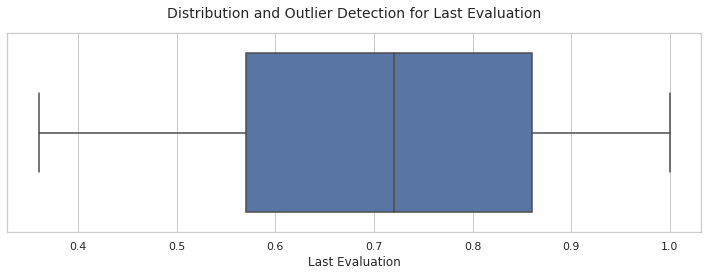

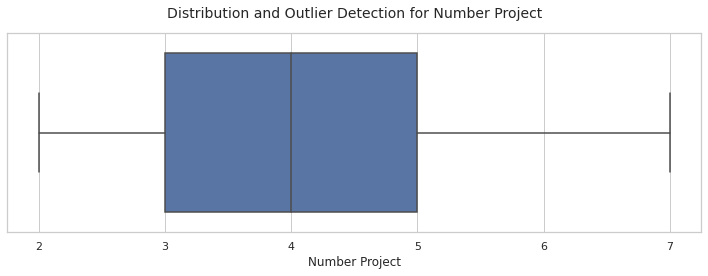

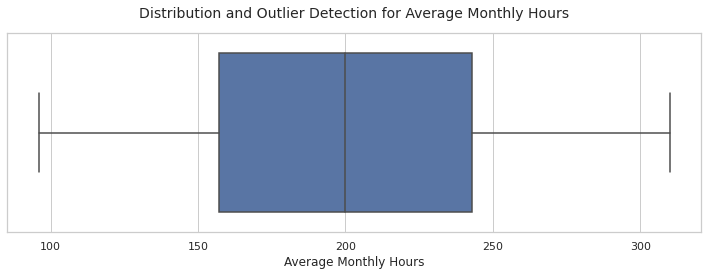

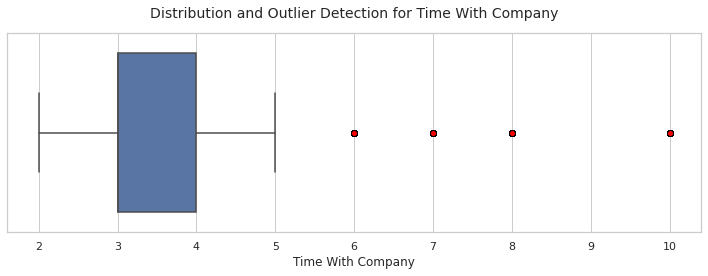

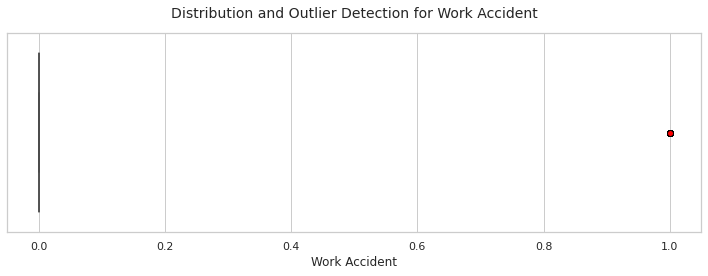

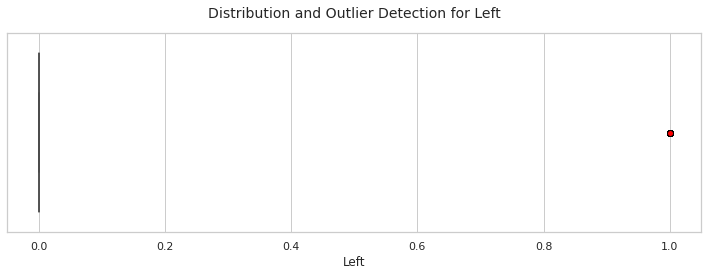

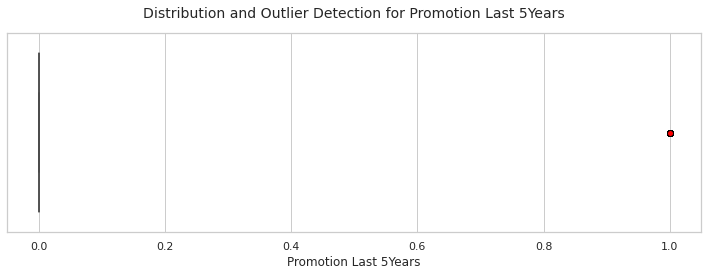

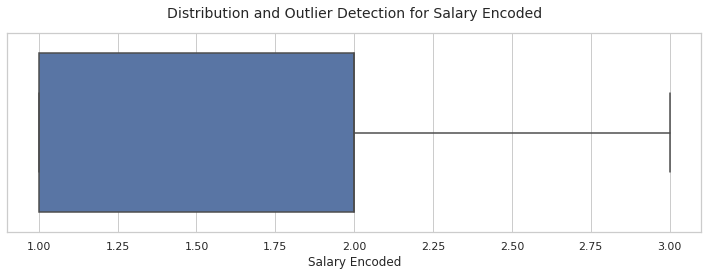

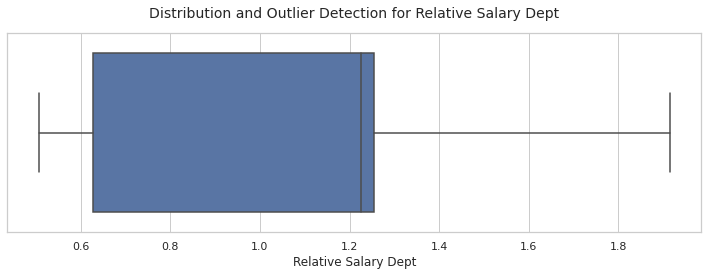

In [17]:
#reuseable function to make box plots for each variable quickly
def generate_whisker_plot(dataframe, column_name):
    """
    Generates a horizontal boxplot for a specified column in a dataframe,
    displaying outliers and formatting labels dynamically.
    """
    # 1. Clean up the column name for neat titles and labels (e.g., 'time_with_company' -> 'Time With Company')
    clean_label = str(column_name).replace('_', ' ').title()
    
    # 2. Initialize the plot style and figure size
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 4))
    
    # 3. Create the boxplot (showfliers=True guarantees outliers are plotted)
    sns.boxplot(
        x=dataframe[column_name], 
        showfliers=True, 
        flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": 6}
    )
    
    # 4. Apply dynamic titles and labels
    plt.title(f'Distribution and Outlier Detection for {clean_label}', fontsize=14, pad=15)
    plt.xlabel(clean_label, fontsize=12)
    
    # 5. Render the plot cleanly
    plt.tight_layout()
    plt.show()
    
numerical_columns = df_encoded.drop(columns='dept').columns
    
for col in numerical_columns:
    generate_whisker_plot(df_encoded, col)


In [18]:
# investigate salary and satisfaction level
df_encoded.groupby('salary_encoded')['satisfaction_level'].mean()
#No significant difference in satisfaction accross different salary levels.

salary_encoded
1    0.622655
2    0.634723
3    0.643343
Name: satisfaction_level, dtype: float64

In [19]:
# Create a plot as needed
df_encoded.groupby('dept')['satisfaction_level'].mean()
#No significant difference in satisfaction level accross department.

dept
IT             0.634016
RandD          0.627176
accounting     0.607939
hr             0.621947
management     0.631995
marketing      0.634770
product_mng    0.629825
sales          0.631349
support        0.634822
technical      0.627937
Name: satisfaction_level, dtype: float64

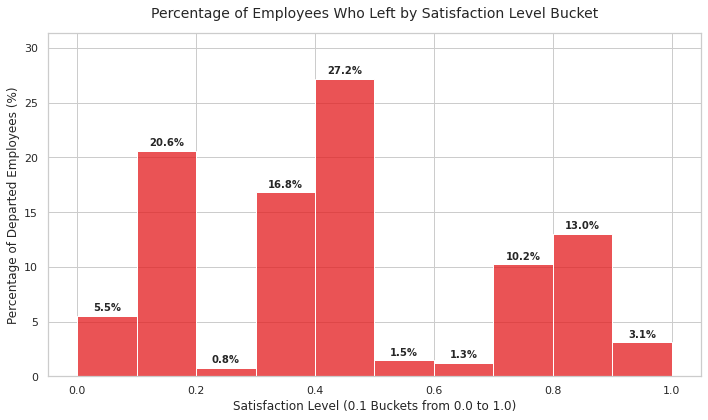

In [29]:
# Let's look at the relationship between satisfaction level and leaving.


# Set the style and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Filter the dataframe to only include employees who left
left_employees = df_encoded[df_encoded['left'] == 1]

# 2. Plot the histogram showing percentage across 10 buckets
ax = sns.histplot(
    data=left_employees,
    x='satisfaction_level',
    bins=10,
    binrange=(0, 1),
    stat="percent",
    color="#e41a1c",
    kde=False,
)

# 3. Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have data
        ax.annotate(
            f"{height:.1f}%",  # Formats to 1 decimal place (e.g., "12.5%")
            (
                p.get_x() + p.get_width() / 2.0,
                height,
            ),  # Position at the top center of the bar
            ha="center",
            va="bottom",
            xytext=(0, 3),  # Offset label slightly above the bar
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Customize titles and labels
plt.title(
    "Percentage of Employees Who Left by Satisfaction Level Bucket",
    fontsize=14,
    pad=15,
)
plt.xlabel("Satisfaction Level (0.1 Buckets from 0.0 to 1.0)", fontsize=12)
plt.ylabel("Percentage of Departed Employees (%)", fontsize=12)

# Adjust y-axis limit slightly higher to prevent top labels from being clipped
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# Render plot cleanly
plt.tight_layout()
plt.show()



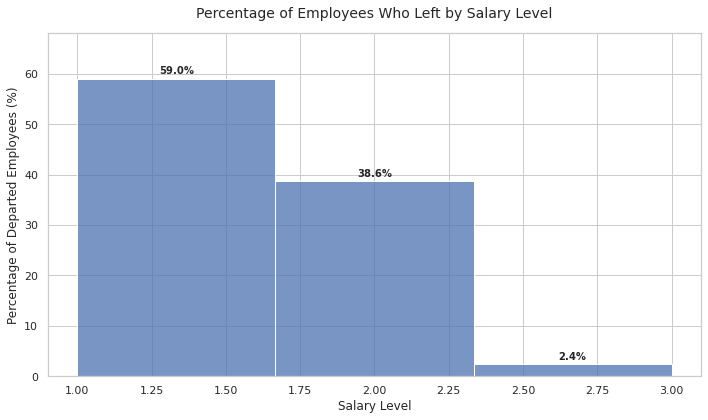

In [35]:
# Let's look at the relationship between salary and who left.

# Set the style and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Filter the dataframe to only include employees who left
left_employees = df_encoded[df_encoded['left'] == 1]

# 2. Plot the histogram showing percentage across 10 buckets
ax = sns.histplot(
    data=left_employees,
    bins=3,
    x='salary_encoded',
    stat="percent",
)

# 3. Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have data
        ax.annotate(
            f"{height:.1f}%",  # Formats to 1 decimal place (e.g., "12.5%")
            (
                p.get_x() + p.get_width() / 2.0,
                height,
            ),  # Position at the top center of the bar
            ha="center",
            va="bottom",
            xytext=(0, 3),  # Offset label slightly above the bar
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Customize titles and labels
plt.title(
    "Percentage of Employees Who Left by Salary Level",
    fontsize=14,
    pad=15,
)
plt.xlabel("Salary Level", fontsize=12)
plt.ylabel("Percentage of Departed Employees (%)", fontsize=12)

# Adjust y-axis limit slightly higher to prevent top labels from being clipped
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# Render plot cleanly
plt.tight_layout()
plt.show()


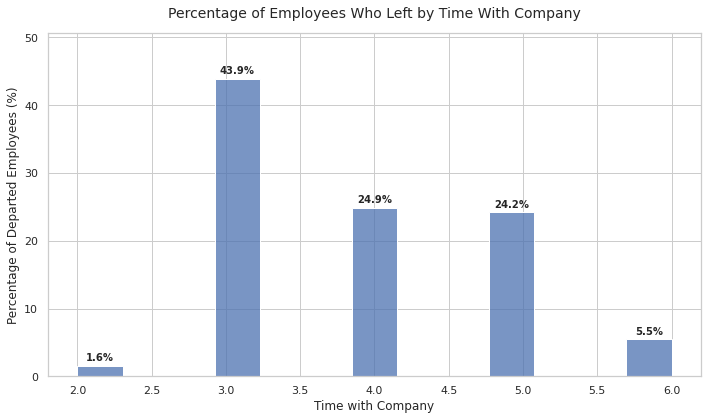

In [33]:
#relationship between time with company and left
# Set the style and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Filter the dataframe to only include employees who left
left_employees = df_encoded[df_encoded['left'] == 1]

# 2. Plot the histogram showing percentage across 10 buckets
ax = sns.histplot(
    data=left_employees,
    x='time_with_company',
    stat="percent",
)

# 3. Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have data
        ax.annotate(
            f"{height:.1f}%",  # Formats to 1 decimal place (e.g., "12.5%")
            (
                p.get_x() + p.get_width() / 2.0,
                height,
            ),  # Position at the top center of the bar
            ha="center",
            va="bottom",
            xytext=(0, 3),  # Offset label slightly above the bar
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Customize titles and labels
plt.title(
    "Percentage of Employees Who Left by Time With Company",
    fontsize=14,
    pad=15,
)
plt.xlabel("Salary Level", fontsize=12)
plt.ylabel("Percentage of Departed Employees (%)", fontsize=12)

# Adjust y-axis limit slightly higher to prevent top labels from being clipped
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# Render plot cleanly
plt.tight_layout()
plt.show()

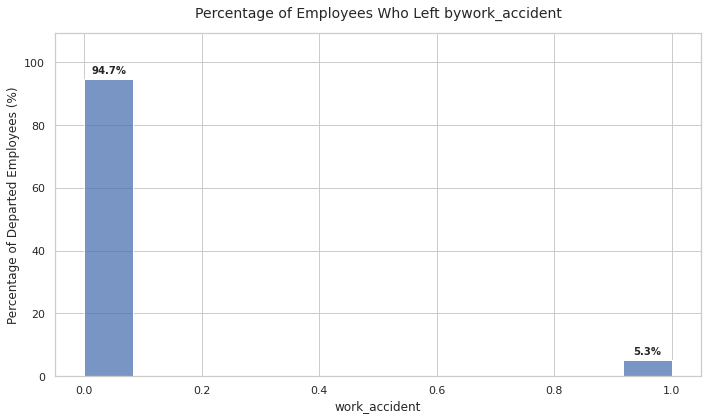

In [52]:
#creating a funciton to make it faster to make these bar charts
#col is the name of the column, MUST BE PASSED IN AS A STRING
def make_hist_chart(col):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # 1. Filter the dataframe to only include employees who left
    left_employees = df_encoded[df_encoded['left'] == 1]

    # 2. Plot the histogram showing percentage across 10 buckets
    ax = sns.histplot(
        data=left_employees,
        x=col,
        stat="percent",
    )

    # 3. Add percentage labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Only label bars that have data
            ax.annotate(
                f"{height:.1f}%",  # Formats to 1 decimal place (e.g., "12.5%")
                (
                    p.get_x() + p.get_width() / 2.0,
                    height,
                ),  # Position at the top center of the bar
                ha="center",
                va="bottom",
                xytext=(0, 3),  # Offset label slightly above the bar
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
            )

    # Customize titles and labels
    plt.title(
        "Percentage of Employees Who Left by"+ col,
        fontsize=14,
        pad=15,
    )
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Percentage of Departed Employees (%)", fontsize=12)

    # Adjust y-axis limit slightly higher to prevent top labels from being clipped
    plt.ylim(0, ax.get_ylim()[1] * 1.1)

    # Render plot cleanly
    plt.tight_layout()
    plt.show()
    
    return

make_bar_chart('work_accident')



In [46]:
#investigate percentage of employees who had a work accident who left
df_encoded[df_encoded['work_accident'] == 1]['left'].value_counts(normalize=True)*100

0    94.324324
1     5.675676
Name: left, dtype: float64

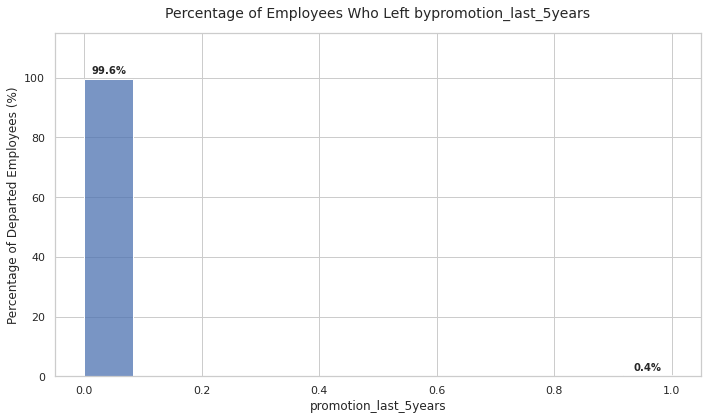

In [53]:
#look at promotion_last_5years and left
make_hist_chart('promotion_last_5years')

In [48]:
#what percentage of pepl actually got a promotion in the last 5 years?
df_encoded['promotion_last_5years'].value_counts(normalize=True)*100

0    98.307064
1     1.692936
Name: promotion_last_5years, dtype: float64

In [49]:
#of those that did get a promotion, how many left?
df_encoded[df_encoded['promotion_last_5years'] == 1]['left'].value_counts(normalize=True)*100

0    96.059113
1     3.940887
Name: left, dtype: float64

In [51]:
#check for class imbalanance 
df_encoded['left'].value_counts(normalize=True)*100
#So, a much lower percentage of people who were promoted in the last 5 years left. Would need to do p-test to be sure statistically significant

0    83.39588
1    16.60412
Name: left, dtype: float64

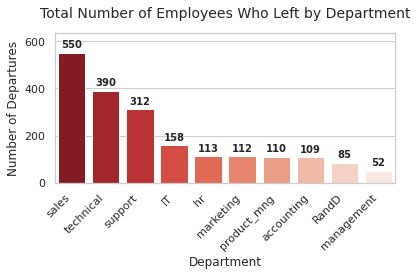

In [54]:
#number of people who left from each department
# 1. Filter dataset for employees who left
left_employees = df[df['left'] == 1]

# 2. Count departures by department and order bars from highest to lowest
dept_counts = left_employees['dept'].value_counts().reset_index()
dept_counts.columns = ['dept', 'count']

# 3. Plot horizontal or vertical bar chart
ax = sns.barplot(
    data=dept_counts,
    x='dept',
    y='count',
    palette='Reds_r'
)

# 4. Add data labels on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f"{height:,}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

# Customize titles and labels
plt.title('Total Number of Employees Who Left by Department', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Departures', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates department labels if text overlaps

# Adjust top y-axis boundary so labels fit nicely
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# Render cleanly
plt.tight_layout()
plt.show()

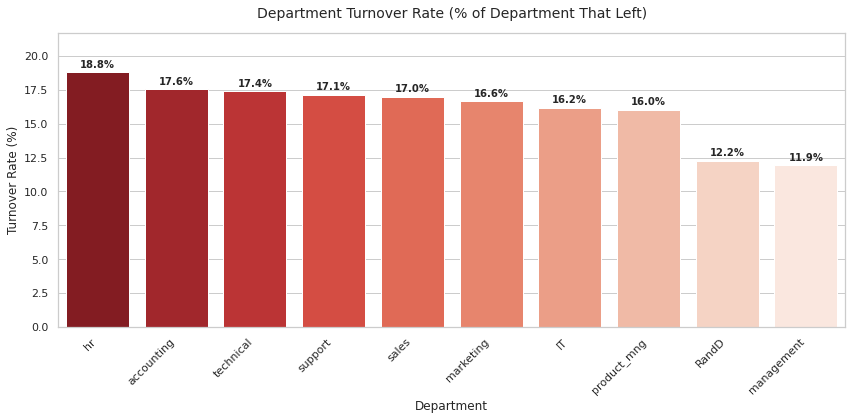

In [55]:
#people who left normalized by dept size
# Set style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Calculate the departure rate (percentage) per department
dept_turnover = (
    df.groupby('dept')['left']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'left': 'turnover_rate'})
    .sort_values(by='turnover_rate', ascending=False)  # Sort highest to lowest
)

# 2. Plot turnover rate by department
ax = sns.barplot(
    data=dept_turnover,
    x='dept',
    y='turnover_rate',
    palette='Reds_r'
)

# 3. Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

# Customize titles and labels
plt.title('Department Turnover Rate (% of Department That Left)', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Turnover Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Adjust y-axis limit so labels don't clip
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# Render cleanly
plt.tight_layout()
plt.show()

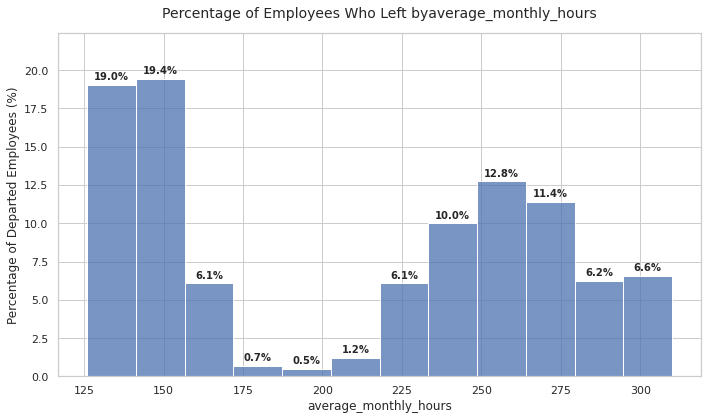

In [57]:
make_hist_chart('average_monthly_hours')

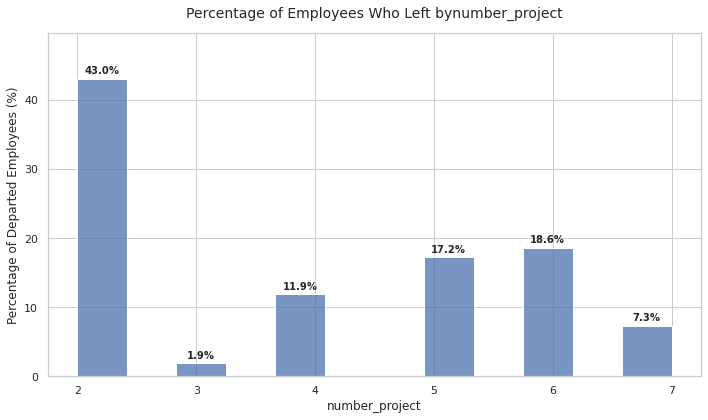

In [58]:
make_hist_chart('number_project')

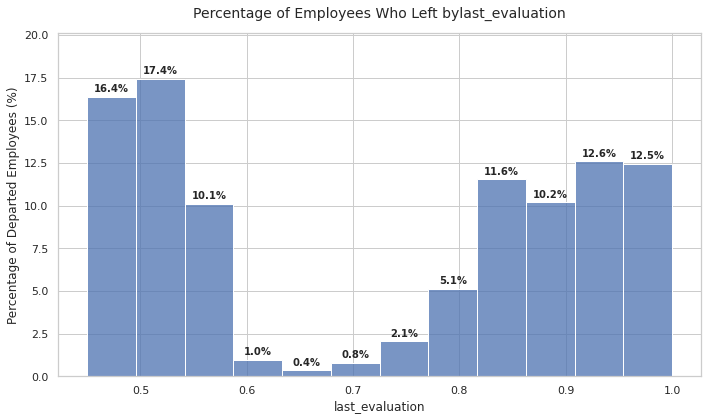

In [59]:
make_hist_chart('last_evaluation')

In [64]:
#make x
X = df_encoded.drop(columns='left')
#make y
y = df_encoded['left']

In [67]:
# split the data into test and training data
# 1. First split: 70% Training, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  # Preserves the 16:84 target ratio in X_train
)

# 2. Second split: Divide the 30% temp data equally into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.50,  # 50% of 30% = 15% of total dataset
    random_state=42, 
    stratify=y_temp  # Preserves ratio in Val and Test
)

# Verify set sizes and proportions
print(f"Training set:   {X_train.shape[0]} samples ({y_train.mean():.1%} positive)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean():.1%} positive)")
print(f"Test set:       {X_test.shape[0]} samples ({y_test.mean():.1%} positive)")

Training set:   8393 samples (16.6% positive)
Validation set: 1799 samples (16.6% positive)
Test set:       1799 samples (16.6% positive)


In [70]:
# encode categorical data in test, val, and training data
# for dept, use target encoding
encoder = TargetEncoder(cols=['dept'], smoothing=10)
#set up the encoder using the train data, so it doesn't leak
X_train['dept_encoded'] = encoder.fit_transform(X_train['dept'], y_train)
#use that same encoder to encode the validation and test data
X_val['dept_encoded'] = encoder.transform(X_val['dept'])
X_test['dept_encoded'] = encoder.transform(X_test['dept'])
#drop the old dept variable
X_train = X_train.drop(columns=['dept'])
X_val = X_val.drop(columns=['dept'])
X_test = X_test.drop(columns=['dept'])

X_train.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_with_company,work_accident,promotion_last_5years,salary_encoded,relative_salary_dept,dept_encoded
8489,0.25,0.98,6,287,5,1,0,1,0.627470,0.178301
3209,0.93,0.66,4,242,4,0,0,1,0.627715,0.158100
2884,0.75,0.78,2,251,6,0,0,2,1.276451,0.171194
6897,0.87,0.54,3,260,2,0,0,2,1.254940,0.178301
6793,0.67,0.63,3,241,3,0,0,2,1.225865,0.174370


### Insights

The only variable with outliers is time_with_company. The people leaving the company tend to have high or low, evaluations, nothing in the middle. The people in the higher salary category are much lsess likely to leave. Employees working low hours or a low number of projects also tend to leave.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Binary (left or not)

### Identify the types of models most appropriate for this task.

I will be using random forest, though logistic regression is also a good option.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [74]:
#set up the grid search for parameters
param_grid = {
    "n_estimators": [100, 200],  # Number of trees
    "max_depth": [6, 8, 10, 12],  # Max depth per tree
    "min_samples_split": [2, 5, 10],  # Min samples required to split an internal node
    "min_samples_leaf": [1, 2, 4],  # Min samples required at a leaf node
    "class_weight": ["balanced"],  # Keeps handling the 16:84 class ratio
}
#instantiate base model
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
#set up grid search
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,  # 5-fold stratified cross-validation
    scoring="f1",  # Optimizes for minority class F1-score
    n_jobs=-1,  # Uses all available CPU cores
    verbose=1,
)

#grid_search.fit(X_train, y_train) <---- commented out so this step doesn't automatically run when restarting
print("Best Hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest Cross-Validation F1-Score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  4.3min finished


Best Hyperparameters found:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross-Validation F1-Score: 0.9435


storing the best fit so we don't have to rerun that step (took about 4 minutes)
Fitting 5 folds for each of 72 candidates, totalling 360 fits
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  4.3min finished
Best Hyperparameters found:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross-Validation F1-Score: 0.9435

In [78]:
#threshold training with validation data
# 1. Extract best model from Grid Search
best_rf = grid_search.best_estimator_

# 2. Get probabilities for minority class (Left = 1) on Validation set
y_val_probs = best_rf.predict_proba(X_val)[:, 1]

# 3. Find threshold that yields the highest F1-score on Validation data
best_threshold = 0.50
best_f1 = 0.0

for threshold in np.arange(0.10, 0.90, 0.02):
    preds = (y_val_probs >= threshold).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(
    f"Optimal Threshold on Validation Set: {best_threshold:.2f} (Val F1: {best_f1:.4f})"
)

Optimal Threshold on Validation Set: 0.46 (Val F1: 0.9568)


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




In [81]:
#test the model with test data!
# 1. Get probabilities on Test set
y_test_probs = best_rf.predict_proba(X_test)[:, 1]

# 2. Apply optimal threshold found in Step 1
y_test_preds = (y_test_probs >= best_threshold).astype(int)

# 3. Print final results
print("--- Final Test Set Results ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_preds))

print("\nClassification Report:")
print(
    classification_report(
        y_test, y_test_preds, target_names=["Stayed (0)", "Left (1)"]
    )
)

--- Final Test Set Results ---
Confusion Matrix:
[[1492    9]
 [  22  276]]

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.99      0.99      0.99      1501
    Left (1)       0.97      0.93      0.95       298

    accuracy                           0.98      1799
   macro avg       0.98      0.96      0.97      1799
weighted avg       0.98      0.98      0.98      1799



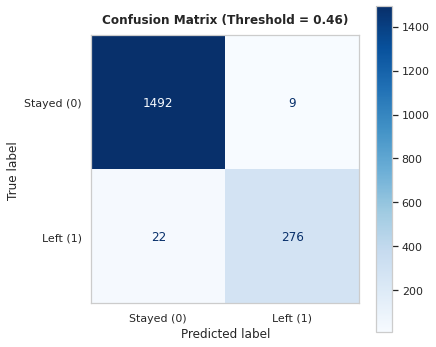

In [85]:
#confusion matrix
# 1. Compute the raw confusion matrix
cm = confusion_matrix(y_test, y_test_preds)

# 2. Display as an interactive 4-box plot
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Stayed (0)", "Left (1)"]
)

# Plot using a clean color map
disp.plot(cmap="Blues", ax=ax, values_format="d")

plt.title(
    f"Confusion Matrix (Threshold = {best_threshold:.2f})",
    fontsize=12,
    pad=12,
    weight="bold",
)
plt.grid(False)  # Turn off background grid lines for clean rendering
plt.show()

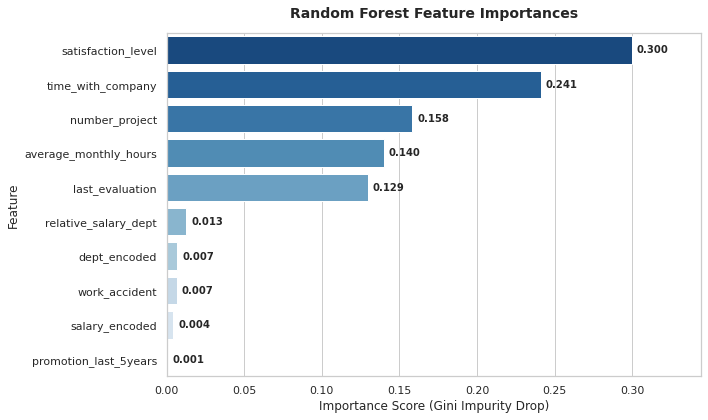

In [87]:
#investigate which variables impacted employee retention the most
# Plot/view top features
# 1. Extract feature importances
importances = pd.Series(
    best_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# 2. Reset index to convert Series into a DataFrame suitable for plotting
importance_df = importances.reset_index()
importance_df.columns = ["Feature", "Importance"]

# 3. Create horizontal bar chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="Blues_r"  # Darkest blue at the top (highest importance)
)

# 4. Add data value labels on each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.3f}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# Customize title and labels
plt.title(
    "Random Forest Feature Importances", fontsize=14, pad=15, weight="bold"
)
plt.xlabel("Importance Score (Gini Impurity Drop)", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Extend x-axis slightly so labels don't clip
plt.xlim(0, max(importances) * 1.15)

# Render plot cleanly
plt.tight_layout()
plt.show()

### Summary of model results

We created a model with an F1 score of .98 to predict whether or not an employee would leave. This model should be used to determine when to reach out to employees likely to leave.
The Feature importances give us insight into which variables affect employee retention.

### Conclusion, Recommendations, Next Steps

Next steps:
- use the model to predict who is likely to leave, and reach out to them to find out how to get them to stay.
- Investigate the factors that go into employee satisfaction, since it is the greatest predictor of whether or not an employee will leave.
- Implement an employee satisfaction program. Ask employees (especially those with low satisfaction scores, etc.) what would make them feel more satisfied.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.